In [35]:
from vae_module import encode, decode, load_vae
from timegan_module import load_timegan
from data_pipeline import inverse_transform, load_scaler
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import pickle

In [36]:
synth_gan = joblib.load("ydata_timegan_latent.pkl")
model_vae = load_vae("vae_checkpoint.pt")
scaler = load_scaler('scaler.pkl')
with open('windows.pkl', 'rb') as f:
    windows = pickle.load(f)

In [ ]:
num_windows = 20
seq_len = 24
latent_dim = 4

np.random.seed(4101)
# Generate
synthetic_latent_raw = synth_gan.sample(num_windows)

# Handle list output from ydata-synthetic 1.4.0
import numpy as np
if isinstance(synthetic_latent_raw, list):
    synthetic_latent_arr = np.array(synthetic_latent_raw)
else:
    synthetic_latent_arr = synthetic_latent_raw.values

print("Raw output shape:", synthetic_latent_arr.shape)

# Reshape depending on what shape came out
# Expected: either (num_windows, seq_len, latent_dim) or (num_windows*seq_len, latent_dim)
if synthetic_latent_arr.ndim == 3:
    synthetic_latent = synthetic_latent_arr  # already (312, 24, 8)
elif synthetic_latent_arr.ndim == 2:
    synthetic_latent = synthetic_latent_arr.reshape(num_windows, seq_len, latent_dim)

print("Synthetic latent shape:", synthetic_latent.shape)

# Decode through VAE
synthetic_normalised = decode(synthetic_latent, model_vae)
print("Synthetic normalised shape:", synthetic_normalised.shape)

#Had to use post processing to match the variance of the real data, otherwise the synthetic data was too "flat" and not useful for downstream tasks. 
# Rescaling to match the real data's variance can help improve the quality of the synthetic samples.
# In normalised space
real_std  = windows.std(axis=(0, 1))      # std per variable
synth_std = synthetic_normalised.std(axis=(0, 1))

# Rescale synthetic to match real variance
synthetic_rescaled = (
    (synthetic_normalised - synthetic_normalised.mean(axis=(0,1), keepdims=True))
    / (synth_std + 1e-8)
) * real_std + windows.mean(axis=(0,1), keepdims=True)

synthetic_original = inverse_transform(synthetic_rescaled, scaler)
print("Synthetic original shape:", synthetic_original.shape)

synthetic_flat = synthetic_original.reshape(-1, synthetic_original.shape[-1])
print(synthetic_flat.shape)  # (480, 8)
columns = ["CPI","TB3MS","M1","M2","AUD_USD","CAD_USD","NZD_USD","ZAR_USD","WTI_price"]
synthetic_df = pd.DataFrame(synthetic_flat, columns = columns)
print(synthetic_df.head())

Raw output shape: (20, 24, 4)
Synthetic latent shape: (20, 24, 4)
Synthetic normalised shape: (20, 24, 9)
Synthetic original shape: (20, 24, 9)
(480, 9)
        CPI     TB3MS        M1        M2   AUD_USD   CAD_USD   NZD_USD  \
0  0.004358 -0.212297  0.012534  0.004338  0.022506  0.005064  0.015055   
1  0.003876 -0.202262  0.012349  0.006365  0.020902  0.014297  0.009913   
2  0.004448 -0.221014  0.012449  0.003750  0.022741  0.003144  0.016198   
3  0.001358 -0.147796  0.002083  0.008630  0.001049  0.021948 -0.016871   
4  0.000385 -0.062454 -0.002015  0.007055 -0.010672  0.009046 -0.019936   

    ZAR_USD  WTI_price  
0 -0.010128   0.068471  
1 -0.003726   0.059669  
2 -0.012044   0.070222  
3  0.035250  -0.022472  
4  0.038035  -0.055524  


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

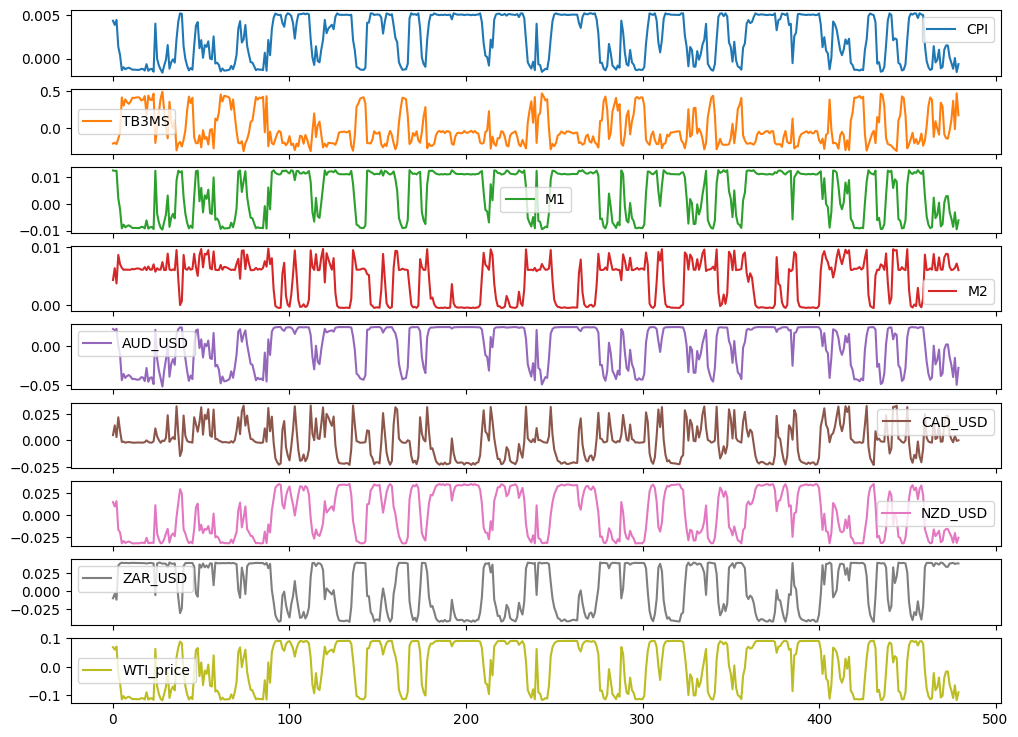

In [49]:
synthetic_df.plot(subplots=True, figsize=(12, 9))